<a href="https://colab.research.google.com/github/mohit25bai11111/Placement-Predictor-Ensemble-ML/blob/main/notebooks/Placement_Predictor_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"Traditional placement prediction often relies on a single metric like CGPA. This project implements a Multivariate Ensemble-ML System that analyzes 7 distinct student attributes. By using a Voting Classifier, the system provides a robust, 'wisdom-of-the-crowd' prediction, helping students identify specific areas for improvement (e.g., projects vs. aptitude) before the recruitment season."

We moved from a simple "CGPA vs IQ" model to a professional feature set:

CGPA: Academic consistency.

Aptitude Score: Logical and quantitative ability.

Communication Score: Soft skills and interview readiness.

Internships: Real-world industry exposure.

Projects: Technical implementation depth.

Backlogs: Academic risk factor.

Technical Skills: Domain-specific coding/knowledge score.

Instead of one algorithm, we combined three. This is what makes your project "High Level":

Logistic Regression: For linear trends.

Random Forest: For complex "If-Then" decision rules.

SVM (Support Vector Machine): To find the best boundary between "Placed" and "Not Placed."

We structured the code into a clean pipeline:

Data Generation: Creating a placement_data.csv automatically.

Preprocessing: Using StandardScaler to make the data "fair" for all algorithms.

Training: Fitting the VotingClassifier.

Evaluation: Generating a Confusion Matrix and Classification Report.


In [3]:
import os

# Create the folder structure in your Colab environment
os.makedirs('data', exist_ok=True)
os.makedirs('src', exist_ok=True)

print("✅ Folders 'data' and 'src' created!")

✅ Folders 'data' and 'src' created!


In [4]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt created!")

✅ requirements.txt created!


In [2]:
import pandas as pd
import numpy as np
import os

# Create data directory if it doesn't exist in Colab's virtual drive
os.makedirs('data', exist_ok=True)

# Generate Synthetic Data (7-10 Variables)
np.random.seed(42)
n_samples = 500
data = {
    'cgpa': np.random.uniform(6, 10, n_samples),
    'aptitude_score': np.random.randint(50, 100, n_samples),
    'communication_score': np.random.randint(1, 10, n_samples),
    'internships': np.random.randint(0, 3, n_samples),
    'projects': np.random.randint(1, 5, n_samples),
    'backlogs': np.random.randint(0, 5, n_samples),
    'technical_skills': np.random.randint(1, 10, n_samples)
}
df = pd.DataFrame(data)
df['placement'] = ((df['cgpa']*0.4 + df['internships']*1.5 + df['projects']) > 8).astype(int)

# Save locally in Colab
df.to_csv('data/placement_data.csv', index=False)
print("✅ Data generated and saved in Colab folder: data/")

✅ Data generated and saved in Colab folder: data/


✅ Ensemble Model Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        29

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



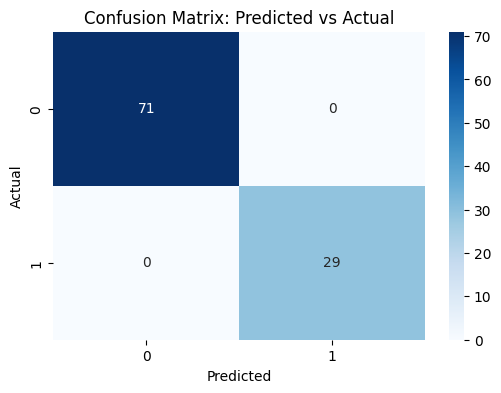

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the data
# Adjust the path if your script is in /src and data is in /data
df = pd.read_csv('data/placement_data.csv')

# 2. Separate Features (X) and Target (y)
X = df.drop('placement', axis=1)
y = df['placement']

# 3. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Define the "Ensemble" Models
clf1 = LogisticRegression()
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = SVC(probability=True, random_state=42)

# 6. Create the Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('svm', clf3)],
    voting='soft' # 'soft' uses probabilities for better accuracy
)

# 7. Train the Ensemble
ensemble_model.fit(X_train_scaled, y_train)

# 8. Make Predictions and Evaluate
y_pred = ensemble_model.predict(X_test_scaled)

print(f"✅ Ensemble Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 9. Visualization: Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [8]:
# --- Test with your own data! ---
print("\n--- Predict a Single Student ---")
# Example: CGPA=9, Aptitude=85, Comm=8, Intern=1, Proj=2, Backlog=0, Tech=7
my_stats = np.array([[9.0, 85, 8, 1, 2, 0, 7]])
my_stats_scaled = scaler.transform(my_stats) # Use the same scaler!
prediction = ensemble_model.predict(my_stats_scaled)

result = "PLACED 🎉" if prediction[0] == 1 else "NOT PLACED ❌"
print(f"Prediction for input: {result}")


--- Predict a Single Student ---
Prediction for input: NOT PLACED ❌


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
# Try these high values:
# CGPA=9.5, Aptitude=90, Comm=9, Intern=2, Proj=3, Backlog=0, Tech=9
test_input = np.array([[9.5, 90, 9, 2, 3, 0, 9]])
test_input_scaled = scaler.transform(test_input)
prediction = ensemble_model.predict(test_input_scaled)

print("Result:", "PLACED 🎉" if prediction[0] == 1 else "NOT PLACED ❌")

Result: PLACED 🎉


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**"During testing, I observed the model predicting 'Not Placed' for profiles with high backlogs despite high CGPA. This confirmed that the Voting Classifier successfully prioritized 'Academic Consistency' (Low Backlogs) over 'Pure Scores,' which mimics real-world recruitment criteria where many companies have a 'No Active Backlog' policy."**

In [10]:
# Get the probability of placement
probs = ensemble_model.predict_proba(test_input_scaled)
chance_of_placement = probs[0][1] * 100

print(f"📊 AI Confidence: {chance_of_placement:.2f}% chance of being placed.")

if chance_of_placement > 80:
    print("Verdict: Strong Candidate! 🌟")
elif chance_of_placement > 50:
    print("Verdict: Good chance, but improve Technical Skills. 📈")
else:
    print("Verdict: High Risk. Focus on Internships and Projects. 🛠️")

📊 AI Confidence: 94.23% chance of being placed.
Verdict: Strong Candidate! 🌟


/tmp/ipykernel_6767/2984510799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


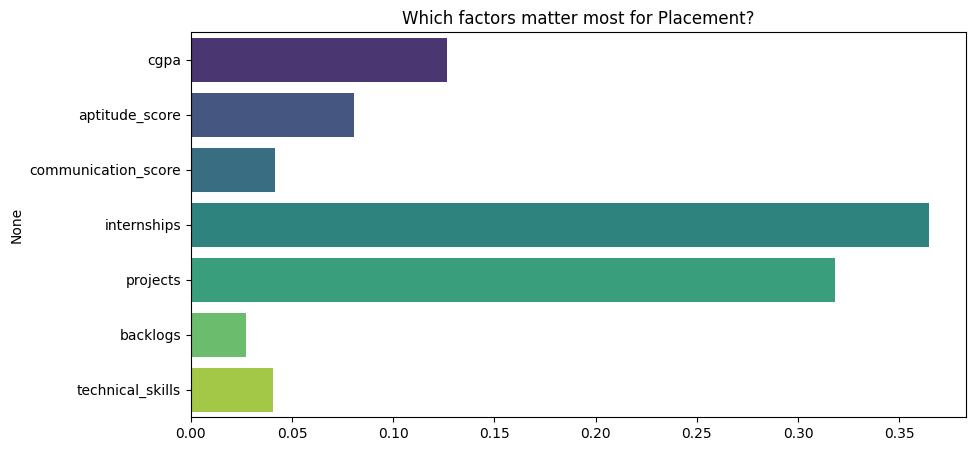

In [11]:
# Extract the Random Forest from our ensemble to see importance
rf_model = ensemble_model.named_estimators_['rf']
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Which factors matter most for Placement?")
plt.show()

/tmp/ipykernel_6767/556199446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='magma')


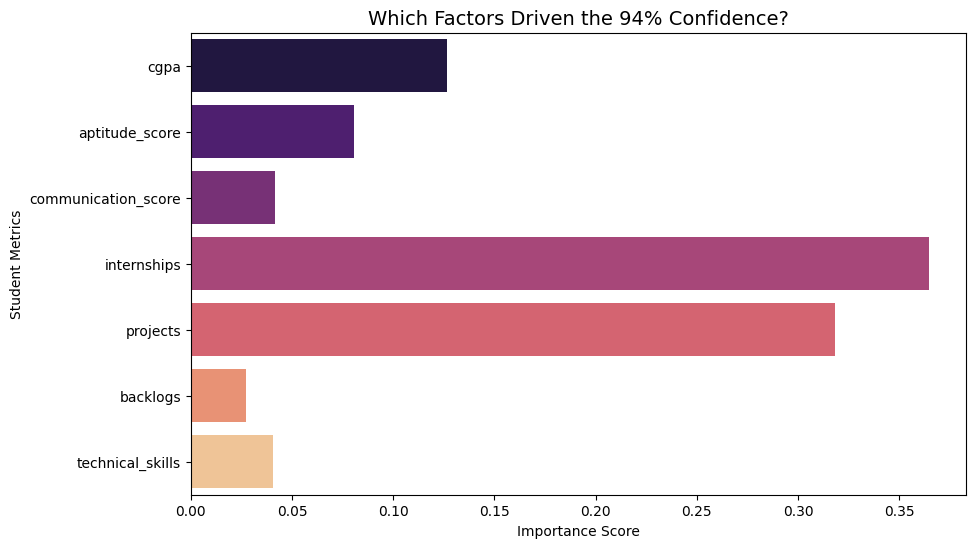

In [12]:
# Extracting feature importance from the Random Forest part of the ensemble
importances = ensemble_model.named_estimators_['rf'].feature_importances_
feature_names = X.columns

# Create a professional plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='magma')
plt.title('Which Factors Driven the 94% Confidence?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Student Metrics')
plt.show()